In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# load modules related to this exercise
from model import model_bufferstock

# Exercise 3 Solving the Buffer-Stock consumption model with EGM

Consider the canonical buffer-stock consumption model.

The exercise will be to add code to $\texttt{model.py}$ such that we can produce life-cycle figures from the Buffer Stock model.

Bellman equation in ratio form: 

$$\begin{align*}
v_{t}(m_{t}) & = & \max_{c_{t}}\left\{ \frac{c_{t}^{1-\rho}}{1-\rho}+\beta\mathbb{E}_{t}\left[(G L_{t} \psi_{t+1})^{1-\rho}v_{t+1}(m_{t+1})\right]\right\} \\
 & \text{s.t.}\\
 a_t & = & m_t-c_t \\
m_{t+1} & = & \frac{1}{G L_t \psi_{t+1}}Ra_t+\xi_{t+1}\\ 
a_t & \geq & \max(-\lambda_t,-\Omega_t) \\
\lambda_t & = & 
\begin{cases} 
\lambda & t < T_R\\
0 & t \geq T_R
\end{cases} \\
\Omega_t & = & \text{Maximum guarenteed repayable debt at time t} \\

\text{For } t<T_R: \\
\psi_{t+1} & \sim & \exp \mathcal{N}(-0.5 \sigma^2_{\psi},\sigma^2_{\psi})\\
\xi_{t+1}& = & \begin{cases}
\mu  &\text{with prob. }\pi\\
(\epsilon_{t+1}-\pi \mu)/ (1-\pi) &\text{else}
\end{cases}\\ \\
\epsilon_{t+1} & \sim & \exp \mathcal{N}(-0.5 \sigma^2_{\xi},\sigma^2_{\xi}) \\

\text{For } t\ge T_R: \\
\psi_{t+1} & = 1 \\
\xi_{t+1} & = 1 \\
\end{align*}$$

and remember:
$$\begin{align*}
Y_{t+1}& = & \xi_{t+1} P_{t+1} \\
P_{t+1}& = & GL_tP_t\psi_{t+1}\\ 
c_t & \equiv & C_t/P_t \\
m_t & \equiv & M_t/P_t \\
a_t & \equiv & A_t/P_t \\
p_t & \equiv & \ln(P_t) \\
y_t & \equiv & \ln(Y_t) \\
\end{align*}$$

The Euler equation is given by:
\begin{align*}
c_t^{-\rho} & = & \beta R \mathbb{E}_{t}\left[(G L_{t} \psi_{t+1})^{-\rho} c_{t+1}^{-\rho}\right] \\
\end{align*}


#### 1. Look at $\texttt{ReadMe.txt}$ to get an overview of the files

#### 2. Ensure you understand the following functions:
<il type ="a">
<li> model.setup </li>
<li> model.create_grids </li>
<li> model.solve</li>
</il>

#### 3. Fill in the missing stuff in the function $\texttt{egm.EGM}$

In [3]:
# load baseline settings
model = model_bufferstock()

In [4]:
model.life_cycle_setup()

# solve and simulate
model.create_grids()
model.solve()
model.simulate()

par = model.par
sol = model.sol
sim = model.sim

#### 4. Run 03_buffer_stock_egm and check that your results are correct

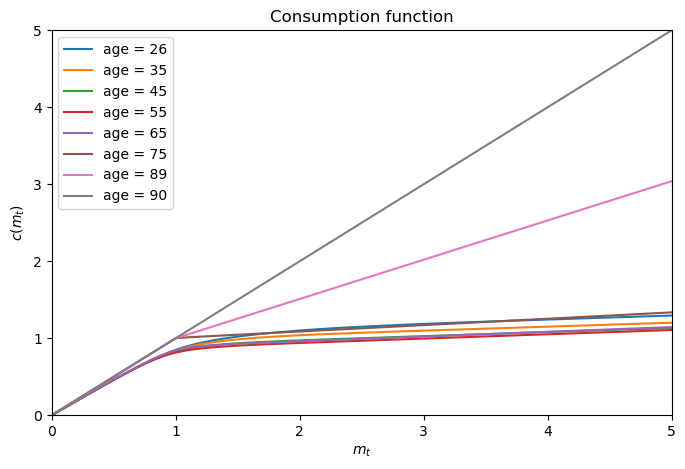

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
for age in [26, 35, 45, 55, 65, 75, par.T+par.age_min-1,par.T+par.age_min] :
    ax.plot(sol.m[age-par.age_min-1,:],sol.c[age-par.age_min-1,:], label=f'age = {age}')
ax.set_xlabel(f"$m_t$")
ax.set_ylabel(f"$c(m_t)$")
ax.set_xlim([np.min(par.a_min), 5])
ax.set_ylim([0,5])
ax.set_title(f'Consumption function')
ax.legend()

Text(0.5, 1.0, 'Average income')

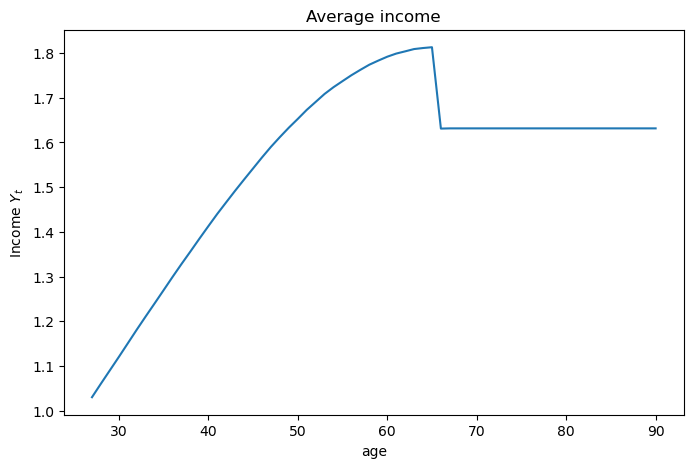

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(np.arange(par.simT)+par.age_min+1,np.mean(sim.Y,1))
ax.set_xlabel(f"age")
ax.set_ylabel(f"Income $Y_t$")
ax.set_title(f'Average income')

Text(0.5, 1.0, 'Average Cash on hands')

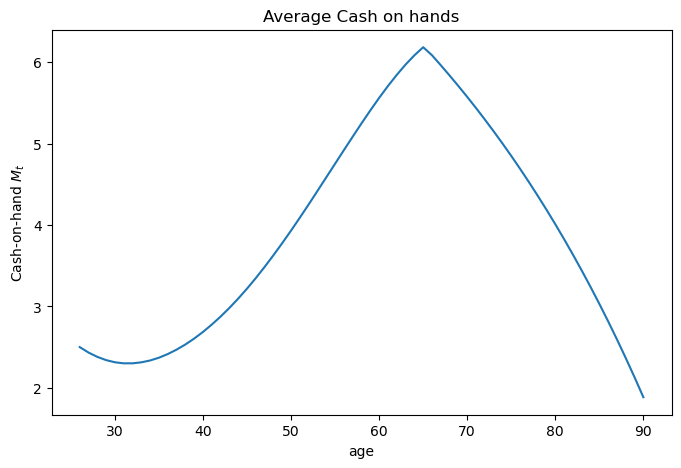

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(np.arange(par.simT)+par.age_min+1,np.mean(sim.M,1))
ax.set_xlabel(f"age")
ax.set_ylabel(f"Cash-on-hand $M_t$")
ax.set_title(f'Average Cash on hands')

Text(0.5, 1.0, 'Average consumption')

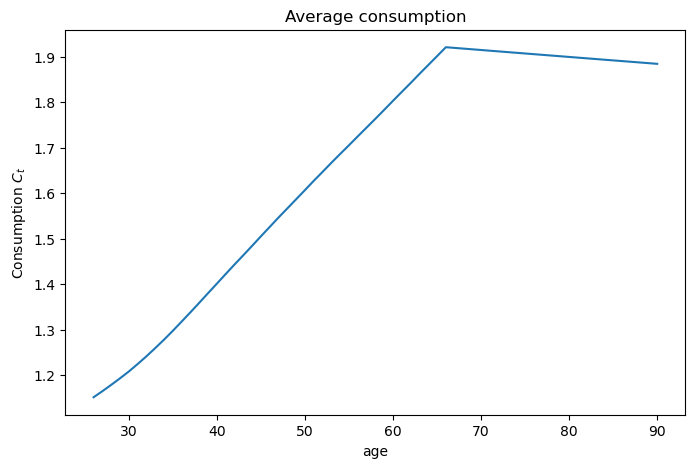

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(np.arange(par.simT)+par.age_min+1,np.mean(sim.C,1))
ax.set_xlabel(f"age")
ax.set_ylabel(f"Consumption $C_t$")
ax.set_title(f'Average consumption')

Text(0.5, 1.0, 'Average Asset')

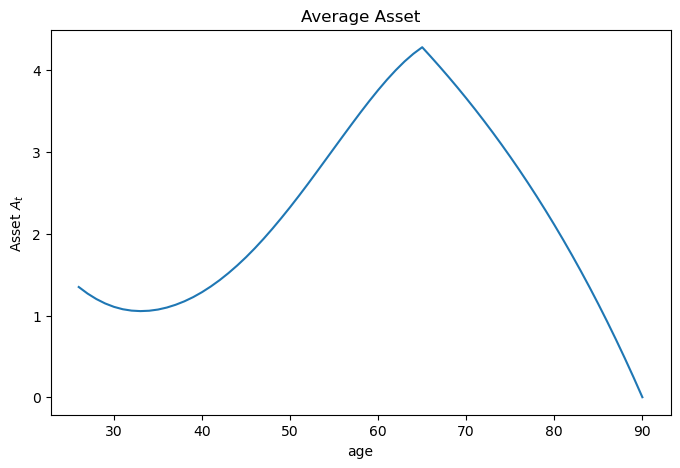

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(np.arange(par.simT)+par.age_min+1,np.mean(sim.A,1))
ax.set_xlabel(f"age")
ax.set_ylabel(f"Asset $A_t$")
ax.set_title(f'Average Asset')

#### 5. (Optional) Could you write a vectorized version of EGM to speed it up? (i.e. without a loop over $a_t$)

In [10]:
# load baseline settings
model_vec = model_bufferstock()
model_vec.life_cycle_setup()
model_vec.par.vec = True

# solve and simulate
model_vec.create_grids()
model_vec.solve()
model_vec.simulate()

par = model_vec.par
sol = model_vec.sol
sim = model_vec.sim

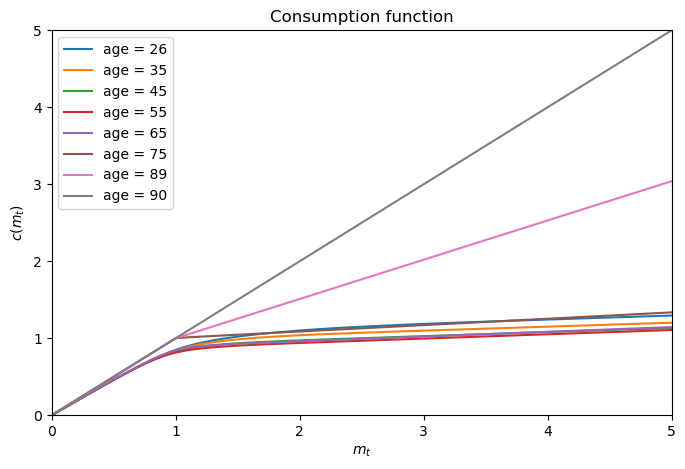

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
for age in [26, 35, 45, 55, 65, 75, par.T+par.age_min-1,par.T+par.age_min] :
    ax.plot(sol.m[age-par.age_min-1,:],sol.c[age-par.age_min-1,:], label=f'age = {age}')
ax.set_xlabel(f"$m_t$")
ax.set_ylabel(f"$c(m_t)$")
ax.set_xlim([np.min(par.a_min), 5])
ax.set_ylim([0,5])
ax.set_title(f'Consumption function')
ax.legend()